# Chapter 27: Calibrate on established products, then adapt for launch
## Goal and setup
Explain known sales across multiple reference products, hold some products out,
and transfer only defensible assumptions. Separate long-horizon trials from
first-year trials and repeat-purchase volume. All records below are synthetic.
The author's gamma convention is peak month 4 and 80% year-one trials;
peak 3 is faster, peak 5 slower. It is a practitioner assumption, not a law.

In [1]:
from pathlib import Path
import sys, json, os
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from forecasting_companion.practitioner import (calibrate_scale, launch_trials,
    gamma_shape, trials_from_reach, cohort_units, evidence_weight)
import pandas as pd
from scipy.stats import gamma
rng=begin(27)
folder=Path(os.environ.get('FORECAST_OUTPUT',project/'companion'))/'results'

## Editable reference-product input table
Population is eligible category buyers; awareness is conditional on eligibility;
availability is conditional on awareness, NOT raw ACV. Interest is conditional
purchase propensity among jointly reached buyers. Units per buyer and observed
sales cover the SAME mature 24-month period. These definitions avoid multiplying
correlated marginal probabilities. Final reach affects potential volume; progress
toward final reach supplies delay. Mature products have no new-launch penalty.

   product      split  observed_units_24m  modeled_units_24m
Product 25 validation             88181.4            83597.9
Product 26 validation            113211.5           113251.7
Product 27 validation             31770.1            33208.8
Product 28 validation            115005.4           114609.7
Product 29 validation             46410.3            46340.1
Product 30 validation             58284.1            53756.1
{'shared_scale': 0.8537686947081796, 'held_out_MAE': 1842.696803765816, 'held_out_MAPE': 0.030043138698697718}


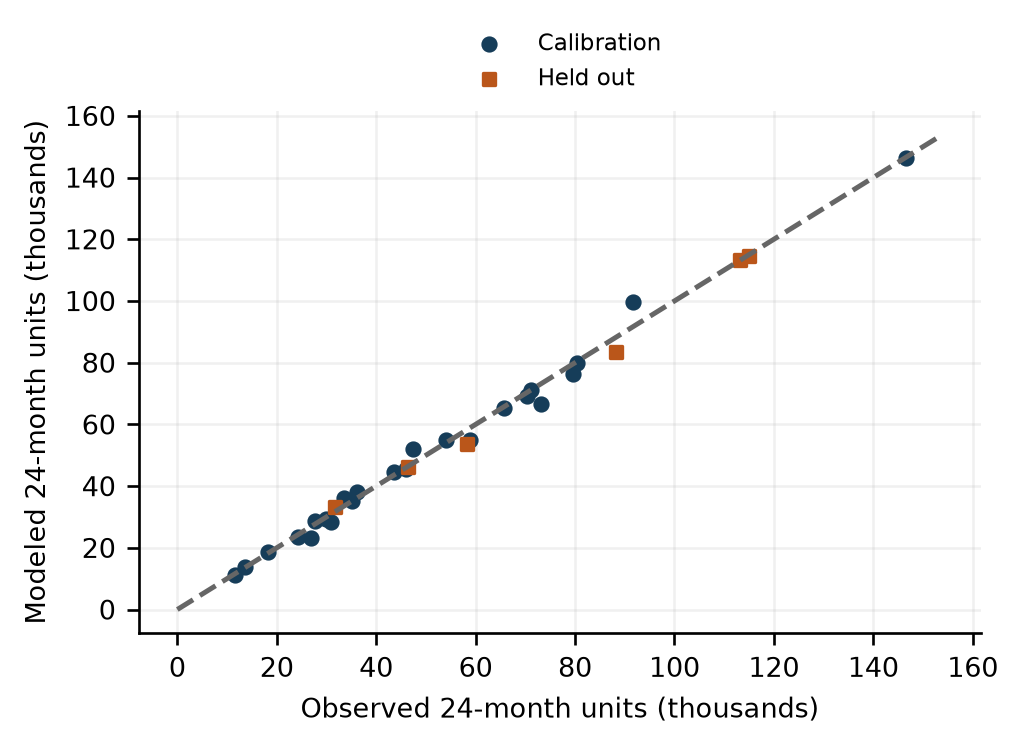

In [2]:
references=pd.DataFrame({
    'product':[f'Product {i+1:02d}' for i in range(30)],
    'eligible_buyers':rng.integers(80000,160000,30),
    'awareness':rng.uniform(.35,.85,30),
    'availability_given_awareness':rng.uniform(.4,.9,30),
    'interest':rng.uniform(.1,.4,30),'units_per_buyer_24m':rng.uniform(3,8,30),
    'research_date':['2025-03-18']*30,'source':['Synthetic educational record']*30,
    'split':['calibration']*24+['validation']*6})
columns=['eligible_buyers','awareness','availability_given_awareness','interest','units_per_buyer_24m']
raw=references[columns].prod(axis=1).to_numpy()
references['observed_units_24m']=raw*.85*rng.lognormal(-.5*.06**2,.06,30)
scale=calibrate_scale(raw[:24],references.observed_units_24m[:24])
references['modeled_units_24m']=raw*scale
references['relative_error']=references.modeled_units_24m/references.observed_units_24m-1
references.to_csv(folder/'ch27-reference-products.csv',index=False)
print(references[['product','split','observed_units_24m','modeled_units_24m']].tail(6).round(1).to_string(index=False))
print({'shared_scale':scale,'held_out_MAE':mae(references.observed_units_24m[24:],raw[24:]*scale),
       'held_out_MAPE':float(abs(references.relative_error[24:]).mean())})
plt.figure()
for mask,label,marker in [(references.split=='calibration','Calibration','o'),(references.split=='validation','Held out','s')]:
    plt.scatter(references.observed_units_24m[mask]/1000,references.modeled_units_24m[mask]/1000,label=label,marker=marker,s=15)
limit=max(references.observed_units_24m.max(),references.modeled_units_24m.max())*1.05/1000
plt.plot([0,limit],[0,limit],'--',color='.4'); plt.xlabel('Observed 24-month units (thousands)'); plt.ylabel('Modeled 24-month units (thousands)'); plt.legend(fontsize=7)
save(27,1,'Can one calibration explain several products?','Thirty synthetic mature products: one shared scale fitted on 24, six held out. Agreement tests the assumed transferable relationship, not its causal truth.','## Section Four: The Build-Up Problem')

## Research age and stability
Record age and market changes. Optional exponential half-lives below are explicit
relevance-weight scenarios, NOT measured decay and NOT sales penalties. They do
not multiply interest. Equal age here means equal weights would not alter the fit.

In [3]:
print('18-month-old evidence: optional relevance weights',{
    months:evidence_weight('2025-03-18','2026-09-18',months) for months in [12,24,48]})
loo=[calibrate_scale(np.delete(raw[:24],i),np.delete(references.observed_units_24m[:24].to_numpy(),i)) for i in range(24)]
print('Leave-one-product-out scale range:',min(loo),max(loo))

18-month-old evidence: optional relevance weights {12: 0.3527993768715904, 24: 0.5939691716508445, 48: 0.7706939545960151}
Leave-one-product-out scale range: 0.8491281935648256 0.8628902152686049


## Adapt the calibrated relationship; define the volume before phasing
New-product reach and interest are scenarios. Transferring the shared scale to
trial conversion is an ADDITIONAL assumption: mature total sales do not separately
identify trial conversion and repeat. Obtain panel/cohort evidence where possible.
This assumption is not validated by the mature-product sales holdout.

In [4]:
new=dict(eligible_buyers=120000,awareness=.65,availability_given_awareness=.70,interest=.28)
trial_total=float(np.prod(list(new.values()))*scale)

## Gamma timing represents awareness/distribution development ONCE
The author confirmed that the standard model allocates all trials over 24 months.
'horizon' is that convention; 'eventual' remains an optional nonstandard comparison.
Standard shape solves mode=4 and F(12)/F(24)=.8, or F(12)=.8 for eventual trials.
Faster/slower cases retain shape and change scale: an implementation convention.
This is the combined awareness/distribution timing, NOT an additional delay.

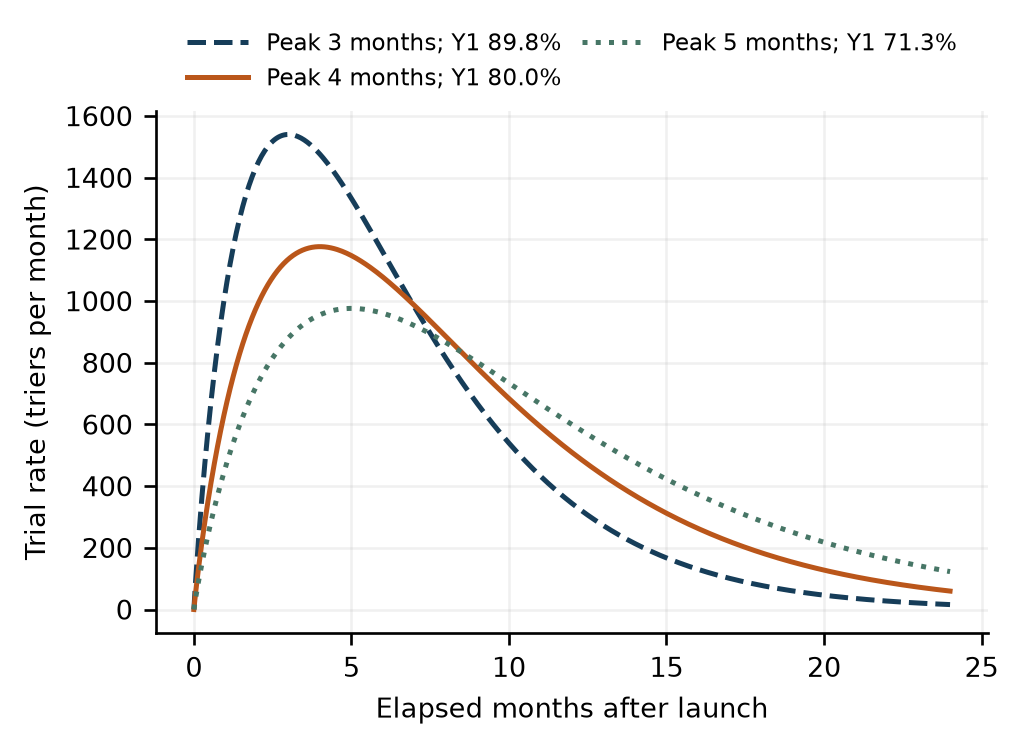

Year-one shares of specified total: {3: 0.8983373225268372, 4: 0.7999999999999998, 5: 0.7130511177133468}
Alternative eventual denominator: {'year1': np.float64(10441.932643758912), 'year2': np.float64(2381.218416727998), 'after_month24': np.float64(229.26474421174134)}


In [5]:
DENOMINATOR='horizon'; HORIZON=24
curves={p:launch_trials(trial_total,peak=p,horizon=HORIZON,denominator=DENOMINATOR) for p in [3,4,5]}
shares={p:float(c[:12].sum()/trial_total) for p,c in curves.items()}
assert shares[3]>shares[4]>shares[5] and np.isclose(shares[4],.8)
if DENOMINATOR=='horizon':
    assert all(np.isclose(c.sum(),trial_total) for c in curves.values())
else:
    assert all(c.sum()<trial_total for c in curves.values())
plt.figure()
timing_shape=gamma_shape(HORIZON,DENOMINATOR)
continuous_months=np.linspace(0,HORIZON,481)
for p,c in curves.items():
    timing_scale=p/(timing_shape-1)
    mass=gamma.cdf(HORIZON,timing_shape,scale=timing_scale) if DENOMINATOR=='horizon' else 1.
    rate=trial_total*gamma.pdf(continuous_months,timing_shape,scale=timing_scale)/mass
    assert np.isclose(continuous_months[np.argmax(rate)],p)
    plt.plot(continuous_months,rate,ls={3:'--',4:'-',5:':'}[p],label=f'Peak {p} months; Y1 {shares[p]:.1%}')
plt.xlabel('Elapsed months after launch'); plt.ylabel('Trial rate (triers per month)'); plt.legend(fontsize=6)
save(27,2,'Build-up changes first-year trial volume',f'Continuous gamma trial rates peak exactly at months 3, 4 and 5. Standard has 80% of the explicit {DENOMINATOR} trial total in year one. Areas under the curves give trial counts; the notebook also calculates monthly totals. Awareness/distribution development is represented once.','## Section Four: The Build-Up Problem')
eventual=launch_trials(trial_total,peak=4,horizon=24,denominator='eventual')
print('Year-one shares of specified total:',shares)
print('Alternative eventual denominator:',{'year1':eventual[:12].sum(),'year2':eventual[12:].sum(),'after_month24':trial_total-eventual.sum()})

## Alternative: explicit progress curves, with no extra gamma multiplier
Factor the SAME joint progress into awareness and conditional availability.
The square-root split is illustrative, not identified. Replace with supported
curves; final reach levels are already in trial_total. Do not count them twice.

In [6]:
shape=gamma_shape(24,DENOMINATOR)
joint=gamma.cdf(np.arange(25),shape,scale=4/(shape-1))
if DENOMINATOR=='horizon': joint/=joint[-1]
awareness_progress=np.sqrt(joint); distribution_progress=np.sqrt(joint)
explicit=trials_from_reach(trial_total,awareness_progress,distribution_progress)
assert np.allclose(explicit,curves[4])

## Trial is not total sales: add repeat cohorts
One unit at trial, then .15 expected units per original trier per month: these are
illustrative assumptions, not observed retention. Later repeat is outside horizon.

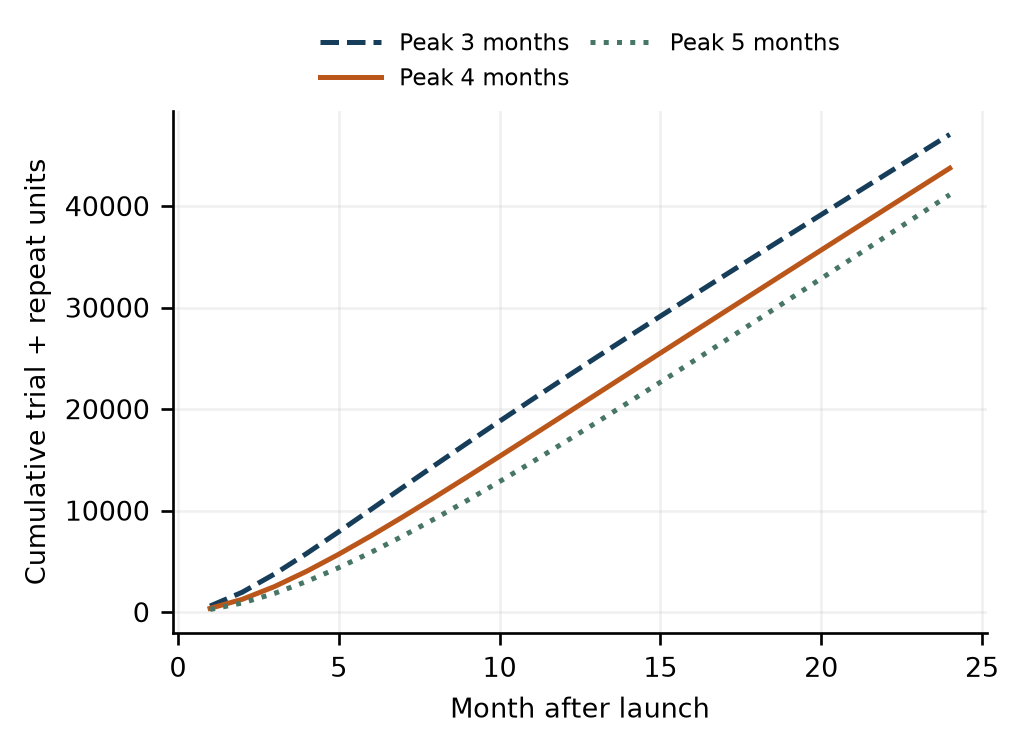

934

In [7]:
kernel=np.r_[1.,np.full(23,.15)]
volume={p:cohort_units(c,kernel) for p,c in curves.items()}
plt.figure()
for p,units in volume.items():
    plt.plot(np.arange(1,25),np.cumsum(units),ls={3:'--',4:'-',5:':'}[p],label=f'Peak {p} months')
plt.xlabel('Month after launch'); plt.ylabel('Cumulative trial + repeat units'); plt.legend(fontsize=7)
save(27,3,'Repeat purchasing changes the volume trajectory',f'Synthetic trial cohorts with an assumed repeat kernel. Equal {DENOMINATOR} trial totals need not yield equal 24-month sales: earlier triers have more time to repeat.','## Section Four: The Build-Up Problem')
monthly=pd.DataFrame({'month':np.arange(1,25),**{f'trials_peak_{p}':c for p,c in curves.items()},**{f'units_peak_{p}':v for p,v in volume.items()}})
monthly.to_csv(folder/'ch27-launch-scenarios.csv',index=False)
record=dict(forecast_date='2026-09-18',outcome_due='2028-09-18',horizon_months=24,
    denominator=DENOMINATOR,denominator_status='author-confirmed standard: horizon; eventual is a nonstandard sensitivity option',
    input_source='synthetic educational inputs',inputs=new,shared_scale=scale,
    trial_total=trial_total,year1_trial_share=shares,repeat_kernel=kernel.tolist(),
    outcome=None,status='illustrative_forecast_unresolved')
(folder/'ch27-input-and-scoring-record.json').write_text(json.dumps(record,indent=2)+'\n')

## The band and its hinge
Step five of the worked example: move one input at a time through the desk model
from chapter 20 and see how far year-one volume moves. The sizes below are what
the illustrative weights imply, not measured elasticities. The result a brand team
does not expect: media spend is a weak lever once awareness nears its plateau;
distribution, category penetration and the evoked-set judgment are the hinges.

base year-one volume 3.545 MM units
                         lever  low_units_mm  high_units_mm  low_pct  high_pct  swing
         Media \$3.5M / \$6.0M         3.432          3.686   -0.032     0.040  0.072
     Share of choice 20% / 33%         3.348          3.861   -0.056     0.089  0.145
        Build peak month 5 / 3         3.178          3.934   -0.104     0.110  0.213
    Brands in evoked set 6 / 4         3.132          3.980   -0.117     0.123  0.239
     Differentiation 110 / 135         3.085          4.061   -0.130     0.145  0.275
        Distribution 55% / 70%         3.027          4.013   -0.146     0.132  0.278
Category penetration 45% / 60%         3.010          4.014   -0.151     0.132  0.283


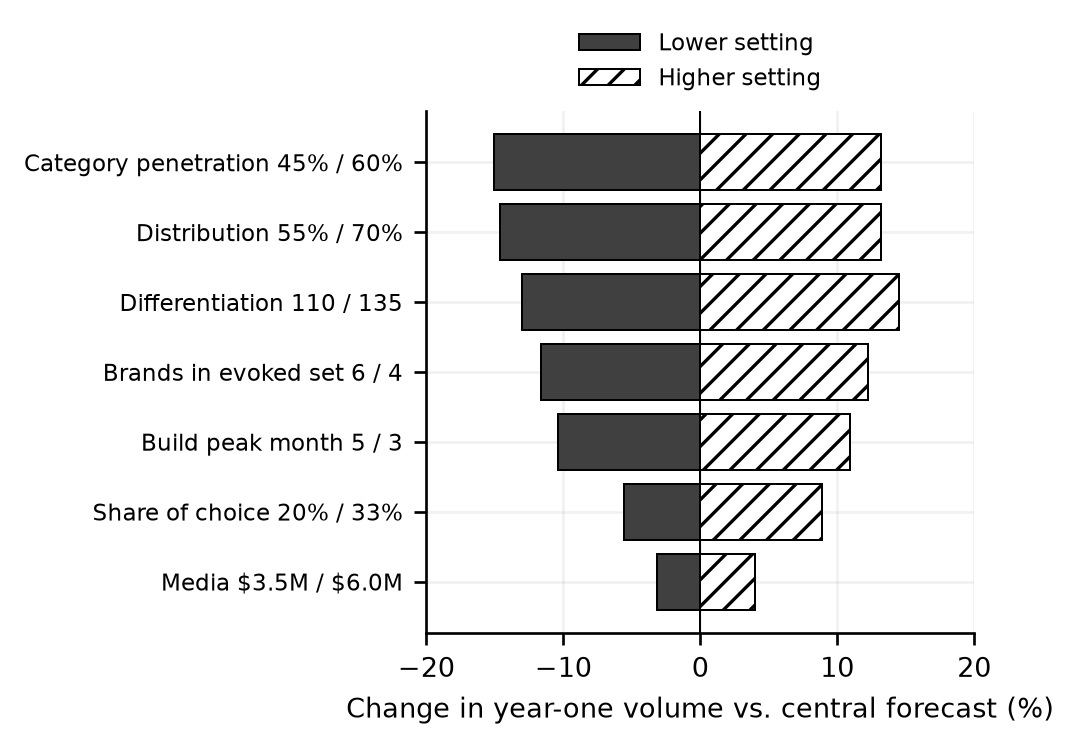

In [8]:
from forecasting_companion import reconcile_sim as rs
desk=rs.run(); base_units=desk.units_mm[0]
def units(**kw):
    hard=rs.HardInputs(**{k:v for k,v in kw.items() if k in rs.HardInputs.__dataclass_fields__})
    opt_kw={k:v for k,v in kw.items() if k in ('build_speed',)}
    det_kw={k:v for k,v in kw.items() if k in rs.TrialDetector.__dataclass_fields__ and k!='coefficients'}
    aw_kw={k:v for k,v in kw.items() if k in rs.AwarenessModel.__dataclass_fields__}
    ov_kw={k:v for k,v in kw.items() if k in rs.Overrides.__dataclass_fields__}
    opt=rs.Options(detector=rs.TrialDetector(**det_kw),awareness=rs.AwarenessModel(**aw_kw),**opt_kw)
    ov=rs.Overrides(**ov_kw) if ov_kw else None
    return rs.run(hard=hard,opt=opt,ov=ov).units_mm[0]
levers=[
    ('Distribution 55% / 70%',units(distribution=.55),units(distribution=.70)),
    ('Category penetration 45% / 60%',units(category_penetration=.45),units(category_penetration=.60)),
    ('Brands in evoked set 6 / 4',units(brands_in_evoked_set=6),units(brands_in_evoked_set=4)),
    ('Differentiation 110 / 135',units(differentiation=110),units(differentiation=135)),
    ('Build peak month 5 / 3',units(build_speed='Somewhat Slow'),units(build_speed='Somewhat Fast')),
    ('Share of choice 20% / 33%',units(share_of_choice=.20),units(share_of_choice=.33)),
    ('Media \\$3.5M / \\$6.0M',units(spending_mm=3.5),units(spending_mm=6.0)),
]
tornado=pd.DataFrame(levers,columns=['lever','low_units_mm','high_units_mm'])
tornado['low_pct']=tornado.low_units_mm/base_units-1; tornado['high_pct']=tornado.high_units_mm/base_units-1
tornado['swing']=tornado.high_pct-tornado.low_pct
tornado=tornado.sort_values('swing')
print(f'base year-one volume {base_units:.3f} MM units'); print(tornado.round(3).to_string(index=False))
assert tornado.set_index('lever').loc['Media \\$3.5M / \\$6.0M','swing']<tornado.set_index('lever').loc['Distribution 55% / 70%','swing']
plt.figure(figsize=(4.3,2.9))
y=np.arange(len(tornado))
plt.barh(y,tornado.low_pct*100,color='#ba561a',label='Lower setting')
plt.barh(y,tornado.high_pct*100,color='#163d59',label='Higher setting')
plt.yticks(y,tornado.lever,fontsize=7); plt.axvline(0,color='black',lw=.6)
plt.xlabel('Change in year-one volume vs. central forecast (%)'); plt.xlim(-20,20)
plt.legend(fontsize=7,ncol=2,loc='upper center',bbox_to_anchor=(.5,1.15),frameon=False)
save(27,4,'Where the launch forecast is fragile','One input moved at a time through the illustrative desk model; bars show the change from the 3.5 million unit central forecast. Distribution, penetration and the evoked-set judgment move the forecast most; media spend moves it least because awareness is near its plateau. Illustrative weights, not measured elasticities.','## Section Four: The Build-Up Problem')
tornado.to_csv(folder/'ch27-sensitivity-tornado.csv',index=False)

## Checks and next steps
Use as many comparable current products as possible, fix measured inputs, fit
shared assumptions on calibration products, then test untouched products. Do not
tune each product independently until it fits. Revisit dated research and vary
uncertain assumptions. Spending effects require separate causal evidence.

## Execute the routing decision before the launch calculation
The chapter is broader than launch timing. A long observed temperature series
supports a historical comparison; four rows do not establish a seasonal process.
The same interface must return different evidence claims for these cases. This
example routes on declared purpose and available history, not on fluent wording.

In [9]:
from forecasting_companion.applied.methods import analyze as route_example
history_input=pd.read_csv(project/'companion/data/observed/monthly-temperature.csv')
history_config={'mode':'history','horizon':12,'season':12,'source':'Public-domain historical temperature snapshot','units':'degrees Celsius'}
history_forecast,history_evidence=route_example(27,history_input,history_config)
sparse_result,sparse_evidence=route_example(27,history_input.tail(4),history_config)
print('Sufficient history:',history_evidence['selected'],'test scores:',history_evidence['test_mae'])
print('Sparse history:',sparse_evidence)
assert sparse_evidence['status']=='needs_evidence' and 'forecast' not in sparse_result

Sufficient history: LightGBM test scores: {'ARIMA(auto)': 0.6475456918276089, 'Airline ARIMA': 0.8695400126899573, 'Damped Holt': 4.552640575938812, 'Drift': 2.4445848306045517, 'ETS(auto)': 0.8503483854085104, 'Holt': 10.829336750817077, 'LightGBM': 1.213353857558351, 'Naive': 2.4441666666666664, 'SES': 2.4441666666666664, 'STL+ETS': 1.488865535590157, 'Seasonal naive': 1.2124999999999988, 'Theta': 0.8477770279425517, 'Equal ensemble': 2.21629053176171, 'Combination(top3)': 0.9180646491805652}
Sparse history: {'status': 'needs_evidence', 'interpretation': 'Sparse history does not establish seasonal structure. Supply defensible reference products, population/reach/trial assumptions and a distinct cross-check; no numeric forecast is manufactured.', 'required_evidence': ['Target and decision', 'Comparable outcomes', 'Defended proxy inputs', 'Uncertainty and scoring plan']}


## A separately supplied capacity check is a bound, not another forecast vote
For this controlled launch only, assume separate outlet research supplies 500
outlets, 12 category units/week/outlet and a 10% attainable brand share over
104 weeks. These are explicit invented teaching inputs, not measured evidence.
Their product bounds a channel scenario independently of the trial-timing curve.
A mismatch should trigger investigation, not automatic averaging of unlike units.

In [10]:
channel_capacity=500*12*.10*104
standard_units=volume[4].sum()
print({'synthetic_channel_capacity_24m':channel_capacity,'trial_repeat_units_24m':float(standard_units),'fraction_of_capacity':float(standard_units/channel_capacity)})
print('Interpretation: the capacity check uses a distinct outlet mechanism, but both routes contain assumptions. Agreement does not calibrate a probability interval.')

{'synthetic_channel_capacity_24m': 62400.0, 'trial_repeat_units_24m': 43726.40777481259, 'fraction_of_capacity': 0.7007437143399454}
Interpretation: the capacity check uses a distinct outlet mechanism, but both routes contain assumptions. Agreement does not calibrate a probability interval.


<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below connect the controlled figures to a complete applied input/output workflow.

# Chapter 27 workshop: from lesson to decision

## Explain the mechanism

Directed forecasting begins with the business question, not the most impressive model. Historical time series, analogues and bottom-up builds have different evidence requirements. A decomposition is useful because its assumptions can be challenged individually. Multiplying uncertain or correlated inputs does not create new evidence.

## Work through the arithmetic

For 100,000 eligible buyers, awareness .5, availability conditional on awareness .6, interest .2 and four units per buyer, raw mature volume is 24,000 units. A shared scale .85 gives 20,400. Transferring .85 to trial conversion is a separate assumption: the implied trial total would be 5,100. Under the standard 24-month convention, year-one trials are .8×5,100=4,080 and year two 1,020; total sales still require repeat cohorts.

Treat this hand calculation as a mechanism check. Compare its units and assumptions with the business target before using the executable adapter below.

## Adapt the lesson to reader data

Replace the references DataFrame in the lesson with observed products and retain an explicit product-level calibration/validation split. Replace new and kernel separately. A single sample row only illustrates format, not adequate calibration. For established-product time series, use the appropriate time-series chapter rather than forcing every problem through launch gamma. Save intake and routing reasoning alongside, not inside, the numerical fit.

Keep the controlled example as a reproducible teaching case. Work in a copy when replacing its data; retain raw input, a cleaned table and an explanation of exclusions. Real data need a named source, extraction date, usable-as-of date and units. If an actual is revised later, preserve the vintage available when the forecast would have been issued. Never silently label synthetic generator output as an external dataset.

For this chapter, settle these questions before fitting: What decision changes with the answer? What target, population, unit, horizon and cutoff apply? Is usable history present? Are analogues comparable and current? Does stated volume mean unique trials or total units? Which genuinely distinct cross-check and eventual scoring outcome are available?

## Interpret the actual lesson outputs

The reference scatter shows synthetic mature-product calibration; validation points test products excluded from fitting. The leave-one-out range measures sensitivity to product selection, not full uncertainty. Gamma scenarios conserve declared trials but move year-one shares. Earlier trials generate more within-horizon repeats, so identical trial totals need not produce identical 24-month sales. The explicit progress example matches gamma by construction and is not independent validation.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `month,peak,trials,units in launch mode; timestamp,forecast,model in history mode`.
- `summary.json`: inspect `scale,trial_total,held_out_mae in launch mode; status/required_evidence in sparse mode`.

Launch requires at least three calibration and two validation products and runs peaks 3,4,5. Explicitly defend scale transfer or supply declared_trial_total; trials may not exceed jointly reached eligible buyers. Supply a constant repeat_rate (one unit at trial) or an explicit repeat_kernel with one nonnegative units-per-trier entry per horizon month. No default repeat assumption is invented; custom timing peaks are not accepted. Standard horizon=24; larger horizons are explicitly different scenarios. mode=estimate and insufficient history return needs_evidence, not a fabricated numeric forecast.

The [fixture](../data/examples/ch27.csv) and [config](../configs/ch27.json) match the current interface. Run the `apply` command in the [skill entrypoint](../../forecasting-skills/forecasting-ch27-directed-forecasting/SKILL.md), using a new empty output folder. Any broader methodology in this workshop requires separately recorded evidence or an explicit extension; successful command execution does not imply those steps happened.

## Decide what the evidence supports

Check product-level residuals and scale instability, out-of-population analogues, double timing, probability denominator errors, unit reconciliation and conservation of the trial total. A mature-product fit validates only the fitted relationship on comparable products, not causal marketing effects or an unmeasured trial-transfer assumption.

If history is sparse, do not fabricate backtests; use explicit analogue/scenario estimates. If repeat data are absent, report trials separately and show repeat assumptions as scenarios. If no distinct cross-check exists, record that absence and the shared-input dependence rather than presenting two formulas as triangulation.

The applied deliverable must make these items inspectable: Return an intake/routing record, proxy/source register, reference-product calibration and held-out errors, monthly trial and total-unit tables, Y1/Y2/tail reconciliation, sensitivity table, missing-evidence priorities and dated scoring plan. State which methods were executed and which remain proposed.

## Three exercises with worked solutions

### Exercise 1

A declared trial total is 4,000. Under standard timing, how many occur in each year?

**Worked solution.** 3,200 in year one and 800 in year two. A slower timing scenario lowers year-one trials while retaining the 4,000 total.

### Exercise 2

Trial cohorts are [100,50], and expected unit kernel is [1,.2]. What are first two months’ sales?

**Worked solution.** Month one is 100. Month two is 50+100×.2=70. The remaining 50×.2=10 repeat units fall after this two-month reporting window.

### Exercise 3

The sales top-down and bottom-up checks both use the same market-size estimate and survey interest. Is their agreement independent validation?

**Worked solution.** No. Record shared evidence and seek a distinct comparison such as observed cohort conversion or comparable launches. Without it, disclose a dependent cross-check.

## Business-reader application

Use this request with the skill:

> Apply chapter 27 to our new product: first determine whether available history supports a model or only an estimate, defend proxy inputs, calibrate across comparable mature products, separate trials from repeat units, preserve 24-month trial totals, and save a forecast/scoring record.

Read the returned result as a decision record. Check that the forecast answers your unit and horizon, that its comparison uses information available at the time, and that any recommendation follows from the stated loss or business objective. Ask which missing measurement would most change the conclusion.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

## Configure and run the applied case

The input file and JSON below are the only entry-point changes needed to try another
case with the same schema. Keep the original examples for comparison. Supply source
and units in the configuration; resolve missing periods rather than silently filling
unknown observations with zeros. These calculations call the same tested functions
as the `run.py apply` command. A failed validation is a reason to inspect the data,
not to replace it with invented observations.

The default input here is a **seeded synthetic schema example**, separate from any
observed-data application below. Read the summary before interpreting its results.

In [11]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json
import pandas as pd
import json, os
INPUT_PATH = project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists()) / 'companion/data/examples/ch27.csv'
CONFIG_PATH = project_path.parents[2] / 'configs/ch27.json'
# Input paths are explicit and may be replaced with reader-supplied files.
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(27, workshop_input, workshop_config)
print(json.dumps(clean_json(workshop_summary), indent=2))
print(workshop_table.head(12).to_string(index=False))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', CONFIG_PATH.parents[1])) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch27-workshop-results.csv', index=False)
(workshop_output/'ch27-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

{
  "scale": 0.8537686947081798,
  "trial_total": 13052.415804698656,
  "held_out_mae": 1842.696803765811,
  "interpretation": "Mature-sales calibration does not identify trial conversion separately from repeat. Transferring the scale is an additional assumption. Modes 3/4/5 are scenarios, not probabilities; the standard allocates 80% of the declared horizon trial total to year one. Repeat rate is units per original trier per subsequent month."
}
 month  peak      trials       units
     1     3  595.919521  595.919521
     2     3 1270.262336 1359.650264
     3     3 1508.894908 1788.822186
     4     3 1517.816753 2024.078268
     5     3 1408.758724 2142.692751
     6     3 1246.702986 2191.950822
     7     3 1069.030482 2201.283766
     8     3  896.339135 2188.946991
     9     3  739.036491 2166.095217
    10     3  601.452315 2139.366515
    11     3  484.413580 2112.545628
    12     3  386.845037 2087.639122


451

## Real-data boundary

The bundled case is controlled, not a reconstruction of historical records. No
verified, appropriately licensed domain dataset is supplied for this particular
workflow. Use the input contract to supply your own observations and evidence.
Do not substitute an unrelated public dataset simply to call the example real.
The wider companion includes observed time-series applications in chapters
3–6, 12, 15–16 and 24; their data do not establish this chapter’s domain assumptions.

## Read the result as a decision record

Start with the summary’s **interpretation**, then examine its numerical evidence.
Distinguish what was fitted, what was supplied, and what remains unidentified.
The results table is the calculation; it is not permission to act. Explain which
assumption would most change the answer and what new evidence would test it.
For a live forecast, set an outcome date and keep the original result for scoring.

The exercises and worked solutions above test interpretation, calculation, and
adaptation. Re-run a changed assumption and compare the actual output; do not
reuse numbers from the book when your input or horizon changes.